In [58]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import cross_val_score

In [20]:
# Load the Excel file using pandas
df = pd.read_excel('G:/OPC-mortar/Database.xlsx')

# Display the dataframe
df

,ID,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)
0,AR,1.09,5.26,4.00,2.29,0.33,46.7798,24.911931,7.17100,331.0,167.0,236.0,50.6
1,AR,0.98,5.18,3.98,2.36,0.32,48.9110,22.960606,6.99284,323.0,173.0,235.0,52.4
2,AR,0.93,5.25,3.94,2.44,0.31,47.7372,24.907551,7.24602,331.0,174.0,240.0,54.8
3,AR,0.98,5.18,4.02,2.47,0.32,47.1548,24.485681,6.92516,319.0,165.0,219.0,50.6
4,AR,0.91,5.12,4.06,2.42,0.31,49.0790,22.661734,6.69848,331.0,166.0,220.0,52.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
308,SAV,2.30,0.48,2.78,3.66,4.90,11.1264,6.799600,19.17235,336.0,170.0,120.0,26.8
309,SAV,2.26,0.55,2.76,3.68,4.88,11.1872,6.712800,19.62595,335.0,160.0,117.0,27.7
310,SAV,2.30,0.54,2.74,3.68,4.90,11.1872,6.765800,20.14935,334.0,160.0,120.0,26.5
311,SAV,2.28,0.54,2.80,3.66,4.88,11.1264,6.746600,19.22420,330.0,160.0,122.0,27.1


In [22]:
# droping the ID column as it is required for ML modeling and data-preprocessing
df = df.drop(["ID"], axis = 1)
df

,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)
0,1.09,5.26,4.00,2.29,0.33,46.7798,24.911931,7.17100,331.0,167.0,236.0,50.6
1,0.98,5.18,3.98,2.36,0.32,48.9110,22.960606,6.99284,323.0,173.0,235.0,52.4
2,0.93,5.25,3.94,2.44,0.31,47.7372,24.907551,7.24602,331.0,174.0,240.0,54.8
3,0.98,5.18,4.02,2.47,0.32,47.1548,24.485681,6.92516,319.0,165.0,219.0,50.6
4,0.91,5.12,4.06,2.42,0.31,49.0790,22.661734,6.69848,331.0,166.0,220.0,52.5
...,...,...,...,...,...,...,...,...,...,...,...,...
308,2.30,0.48,2.78,3.66,4.90,11.1264,6.799600,19.17235,336.0,170.0,120.0,26.8
309,2.26,0.55,2.76,3.68,4.88,11.1872,6.712800,19.62595,335.0,160.0,117.0,27.7
310,2.30,0.54,2.74,3.68,4.90,11.1872,6.765800,20.14935,334.0,160.0,120.0,26.5
311,2.28,0.54,2.80,3.66,4.88,11.1264,6.746600,19.22420,330.0,160.0,122.0,27.1


In [24]:
# Checking for missing values
missing_values = df.isnull().sum()

# Displaying the number of missing values for each column (it will show the sum
# of the number of missing values rows for each column)
print("Missing values in each column:")
missing_values

Missing values in each column:


LOI (%)                0
Al2O3 (%)              0
Fe2O3 (%)              0
SO3 (%)                0
Na2O (%)               0
C3S                    0
C2S                    0
C3A                    0
Blaine (m2/kg)         0
Setting int (min)      0
Setting final (min)    0
28-days CS (MPa)       0
dtype: int64

In [26]:
# Remove all rows containing missing values
df_cleaned = df.dropna()

df_cleaned[df_cleaned.duplicated(keep=False)]

,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min),28-days CS (MPa)


In [28]:
# showing the basic statistical information
descript=df_cleaned.describe().T
descript

,count,mean,std,min,25%,50%,75%,max
LOI (%),313.0,1.946994,0.634235,0.70000,1.510000,2.110000,2.280000,3.440000
Al2O3 (%),313.0,4.783821,0.934708,0.48000,4.630000,4.980000,5.180000,5.630000
Fe2O3 (%),313.0,3.710571,0.366575,2.70000,3.520000,3.640000,3.970000,4.960000
SO3 (%),313.0,2.443040,0.411471,1.42000,2.200000,2.420000,2.690000,3.680000
Na2O (%),313.0,0.609088,0.906668,0.16000,0.310000,0.370000,0.640000,4.940000
C3S,313.0,50.199046,9.215470,11.06560,47.875900,51.658460,55.970750,59.880000
C2S,313.0,20.333666,4.593159,6.71280,17.489226,21.152546,23.504779,31.974438
C3A,313.0,7.342388,2.650107,4.11568,6.112860,6.964100,7.654340,21.001300
Blaine (m2/kg),313.0,317.292722,23.620384,270.00000,301.000000,314.000000,333.000000,389.000000
Setting int (min),313.0,147.475054,18.731059,120.00000,132.000000,140.000000,160.000000,196.000000


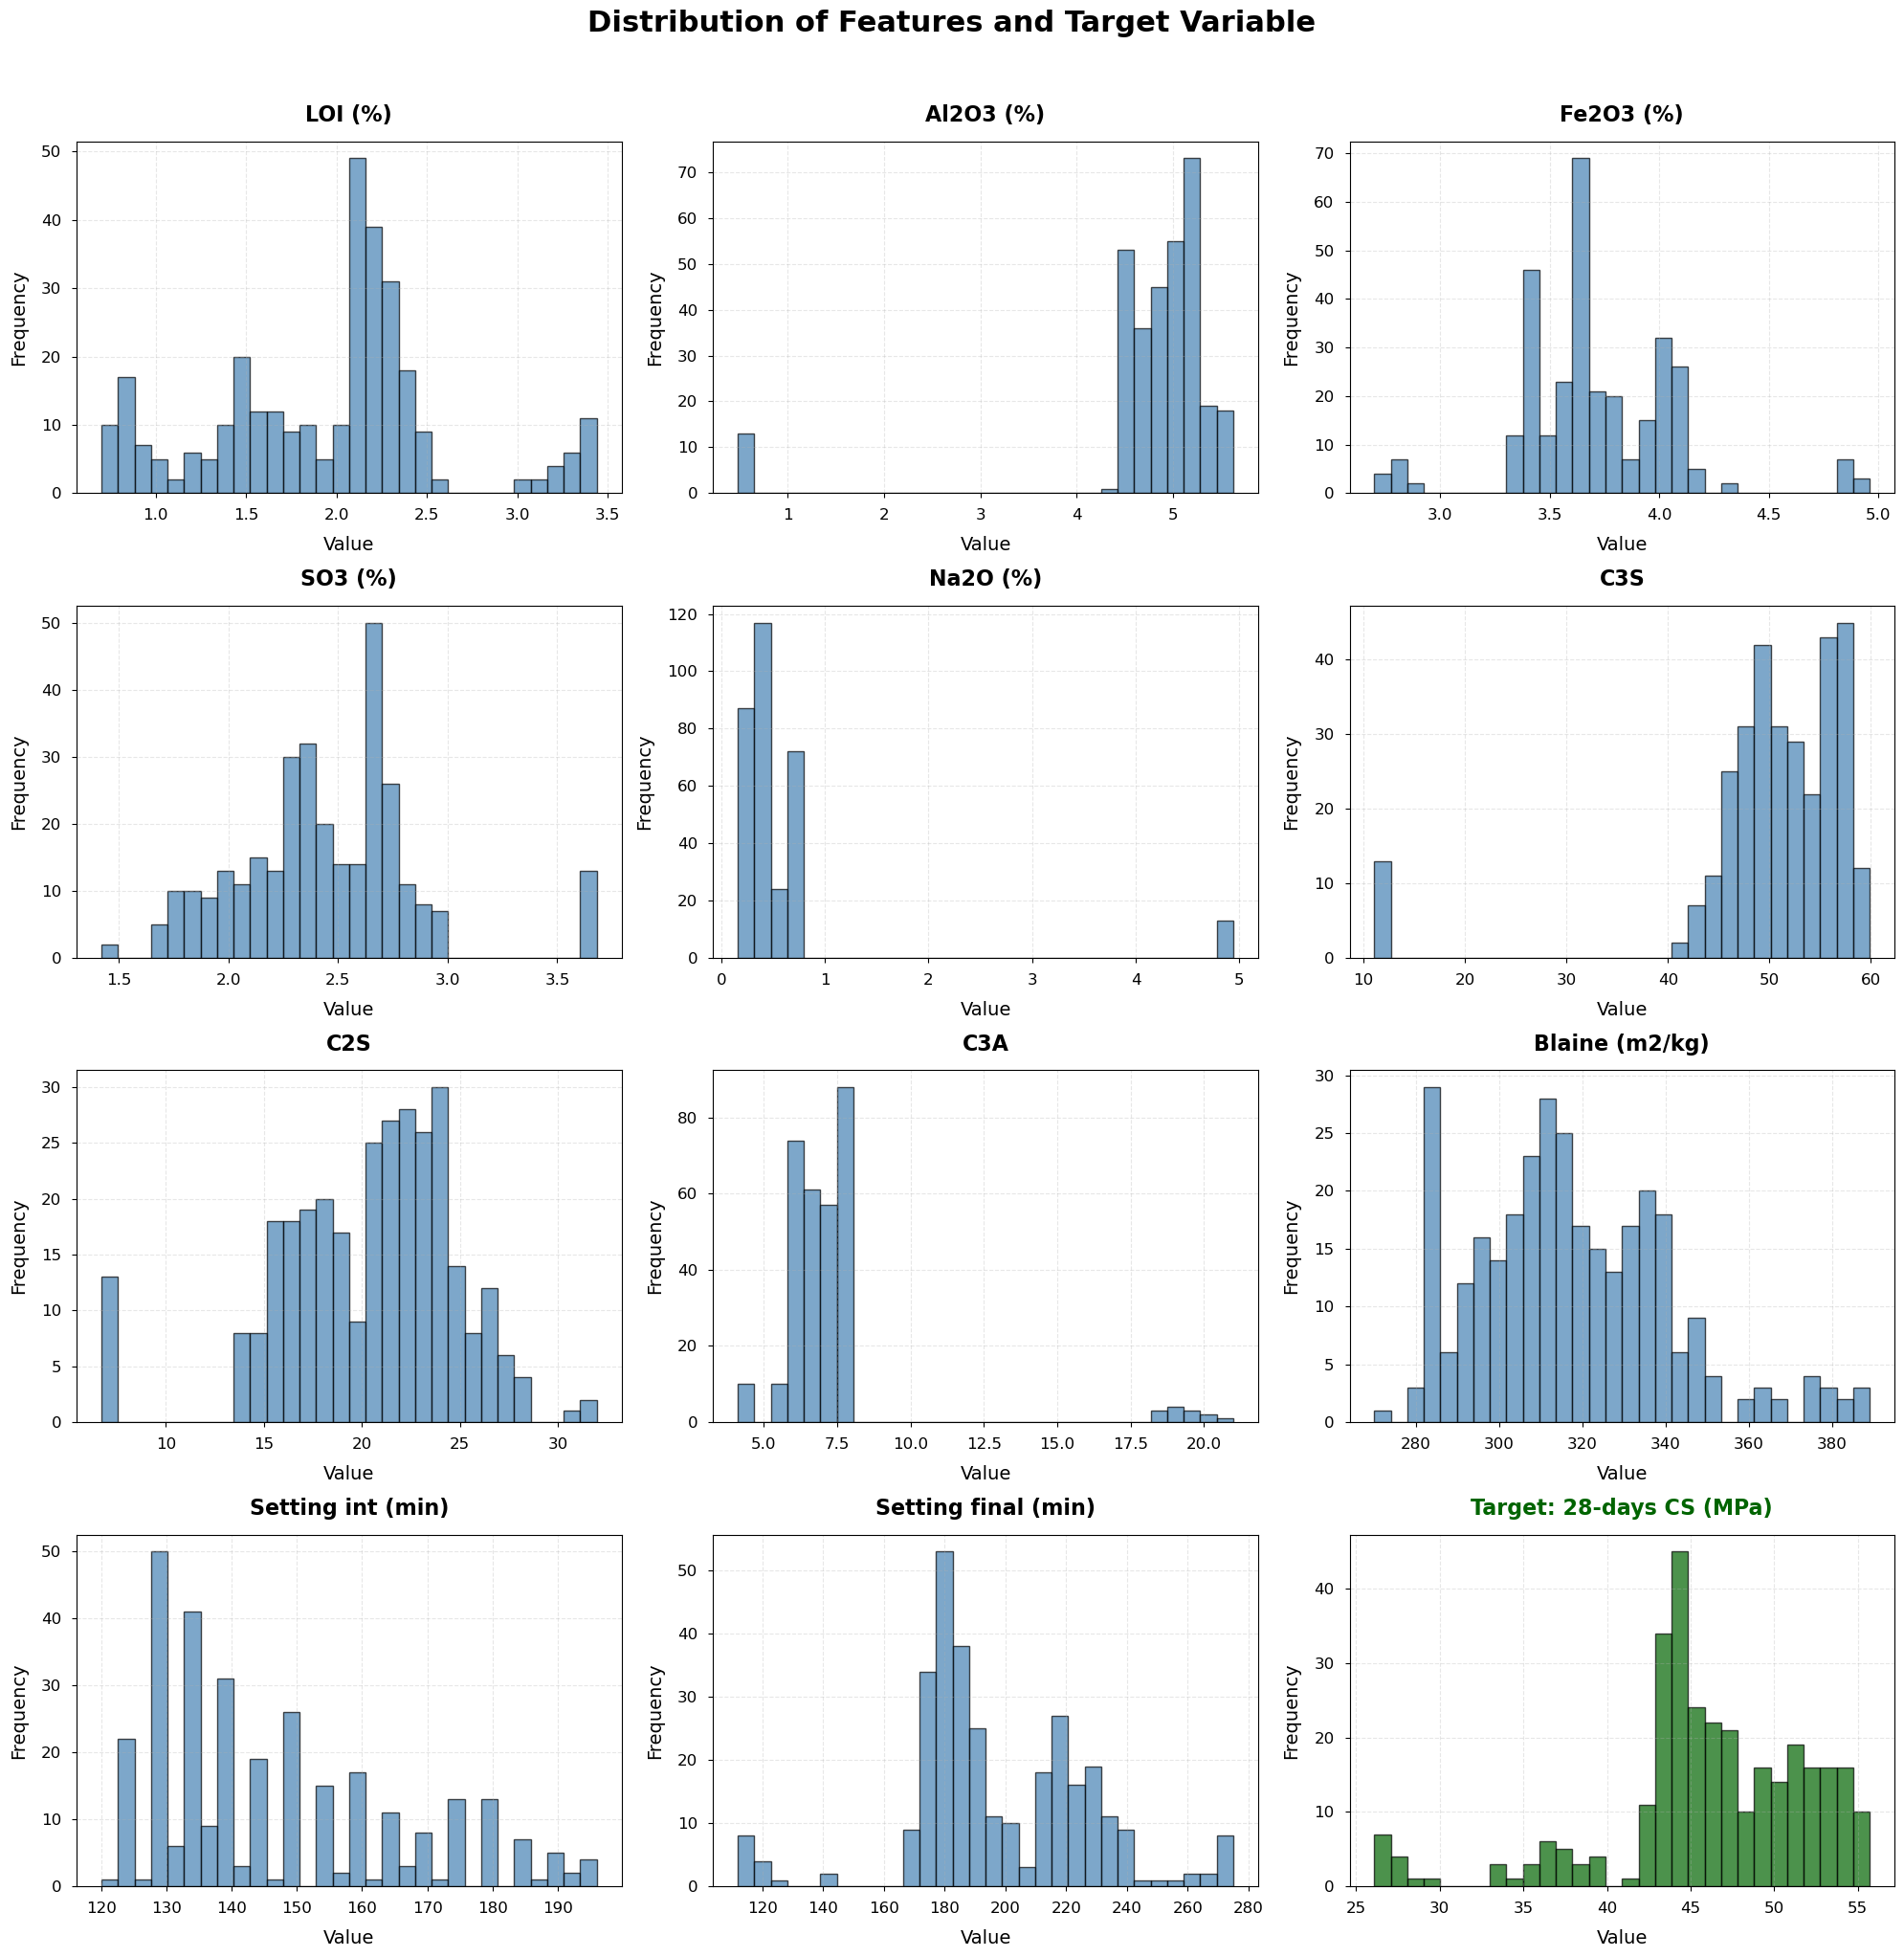

In [30]:
# Making dataset histograms
# Set global font size
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

# Assuming 'target' is your target variable column name
target_column = '28-days CS (MPa)'
feature_columns = [col for col in df_cleaned.columns if col != target_column]

# Calculate grid size with 3 columns
n_features = len(feature_columns)
n_cols = 3
n_rows = int(np.ceil((n_features + 1) / n_cols))

# Create subplots with larger figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*5))
axes = axes.flatten()

# Plot histograms for features
for i, column in enumerate(feature_columns):
    axes[i].hist(df_cleaned[column].dropna(), bins=30, 
                 edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_title(f'{column}', fontsize=16, fontweight='bold', pad=15)
    axes[i].set_xlabel('Value', fontsize=14, labelpad=10)
    axes[i].set_ylabel('Frequency', fontsize=14, labelpad=10)
    axes[i].grid(alpha=0.3, linestyle='--')
    axes[i].tick_params(axis='both', which='major', labelsize=12, pad=8)

# Plot target histogram
target_idx = len(feature_columns)
axes[target_idx].hist(df_cleaned[target_column].dropna(), bins=30, 
                      color='darkgreen', edgecolor='black', alpha=0.7)
axes[target_idx].set_title(f'Target: {target_column}', fontsize=16, 
                           fontweight='bold', color='darkgreen', pad=15)
axes[target_idx].set_xlabel('Value', fontsize=14, labelpad=10)
axes[target_idx].set_ylabel('Frequency', fontsize=14, labelpad=10)
axes[target_idx].grid(alpha=0.3, linestyle='--')
axes[target_idx].tick_params(axis='both', which='major', labelsize=12, pad=8)

# Hide empty subplots
for i in range(target_idx + 1, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution of Features and Target Variable', 
             fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
# for data scaling there are two methods: normalization and standardization
# in this case we used normalization method

#distinguishing between features and target
features = df_cleaned.drop(["28-days CS (MPa)"], axis = 1)
target_reg = df_cleaned["28-days CS (MPa)"]


#importing the library that has MinMaxScalar
from sklearn.preprocessing import MinMaxScaler

#Step1
scalar = MinMaxScaler()

#Step 2 and 3
scaled_feature = scalar.fit_transform(features)
scaled_feature = pd.DataFrame(scaled_feature, columns=features.columns)
scaled_feature

,LOI (%),Al2O3 (%),Fe2O3 (%),SO3 (%),Na2O (%),C3S,C2S,C3A,Blaine (m2/kg),Setting int (min),Setting final (min)
0,0.142336,0.928155,0.575221,0.384956,0.035565,0.731632,0.720426,0.180942,0.512605,0.618421,0.760736
1,0.102190,0.912621,0.566372,0.415929,0.033473,0.775292,0.643181,0.170391,0.445378,0.697368,0.754601
2,0.083942,0.926214,0.548673,0.451327,0.031381,0.751246,0.720252,0.185385,0.512605,0.710526,0.785276
3,0.102190,0.912621,0.584071,0.464602,0.033473,0.739315,0.703552,0.166383,0.411765,0.592105,0.656442
4,0.076642,0.900971,0.601770,0.442478,0.031381,0.778733,0.631350,0.152959,0.512605,0.605263,0.662577
...,...,...,...,...,...,...,...,...,...,...,...
308,0.583942,0.000000,0.035398,0.991150,0.991632,0.001246,0.003436,0.891686,0.554622,0.657895,0.049080
309,0.569343,0.013592,0.026549,1.000000,0.987448,0.002491,0.000000,0.918549,0.546218,0.526316,0.030675
310,0.583942,0.011650,0.017699,1.000000,0.991632,0.002491,0.002098,0.949546,0.537815,0.526316,0.049080
311,0.576642,0.011650,0.044248,0.991150,0.987448,0.001246,0.001338,0.894757,0.504202,0.526316,0.061350


In [34]:
# divide the dataset into two groups: features and target_reg and target_class
X_reg = scaled_feature.copy(deep=True)
y_reg = target_reg.copy(deep=True)

# divide the dataset into four groups: Train and test features and train and test target
# import the library that can split the dataset
from sklearn.model_selection import train_test_split

#for regression problem
X_train_reg , X_test_reg , y_train_reg , y_test_reg = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = 11)


# Display the shapes of the train and test sets for regression
print(f"X_train_shape: {X_train_reg.shape}")
print(f"X_testshape: {X_test_reg.shape}")

print(f"y_reg_train_shape: {y_train_reg.shape}")
print(f"y_reg_test_shape: {y_test_reg.shape}")

X_train_shape: (219, 11)
X_testshape: (94, 11)
y_reg_train_shape: (219,)
y_reg_test_shape: (94,)


In [38]:
# import the library that have the metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Function to evaluate the predictions
def evaluate_predictions(y_true, y_pred):
    
    MAE = mean_absolute_error(y_true, y_pred)
    MSE = mean_squared_error(y_true, y_pred)
    RMSE = np.sqrt(MSE)
    MAPE = mean_absolute_percentage_error(y_true, y_pred)
    R2 = r2_score(y_true, y_pred)
    
    return MAE, MSE, RMSE, MAPE, R2


# Function to print results
def print_results(metrics, dataset_type):
    
    MAE, MSE, RMSE, MAPE, R2 = metrics
    
    print(f'{dataset_type} MAE = {round(MAE, 3)}')
    print(f'{dataset_type} MSE = {round(MSE, 3)}')
    print(f'{dataset_type} RMSE = {round(RMSE, 3)}')
    print(f'{dataset_type} MAPE = {round(MAPE, 3)}%')  # this is in percentage
    print(f'{dataset_type} R2 = {round(R2, 3)}%\n')   # this is in percentage

    
    
# Helper function to create scatter plots
def create_combined_scatter_plot(ax, x_train, y_train, x_test, y_test, 
                                train_metrics, test_metrics, colors):
    # Combine data for line range calculation
    combined_actual = np.concatenate([x_train, x_test])
    combined_predicted = np.concatenate([y_train, y_test])
    
    # Calculate data range for axis limits
    data_min = min(np.min(combined_actual), np.min(combined_predicted))
    data_max = max(np.max(combined_actual), np.max(combined_predicted))
    
    # Add padding (5% of the data range)
    padding = 0.05 * (data_max - data_min)
    
    # Adjust lower limit to prevent negative values if data starts at 0
    adjusted_data_min = data_min - padding
    if data_min >= 0:
        adjusted_data_min = max(adjusted_data_min, 0)
    
    # Set axis limits to ensure same range for X and Y
    ax.set_xlim(adjusted_data_min, data_max + padding)
    ax.set_ylim(adjusted_data_min, data_max + padding)
    
    # Set aspect ratio to 'equal' for 45-degree line
    ax.set_aspect('equal')
    
    # Plot both datasets
    ax.scatter(x_train, y_train, color=colors[0], edgecolors='black', label='Train')
    ax.scatter(x_test, y_test, color=colors[1], edgecolors='black', label='Test')
    
    # Plot reference lines
    min_val = adjusted_data_min  # Use adjusted lower bound with padding
    max_val = data_max + padding  # Use adjusted upper bound with padding
    
    ax.plot([min_val, max_val], [min_val, max_val], 
            color='gray', linestyle='-.', label='X=Y')
    
    # Set labels
    ax.set_xlabel('Actual Compressive Strength (MPa)')
    ax.set_ylabel('Predicted Compressive Strength (MPa)')
    
    # Create combined metrics text
    train_text = (f"Train:\nMAE = {train_metrics[0]:.3f}\n"
                 f"RMSE = {train_metrics[2]:.3f}\n"
                 f"$R^2$ = {train_metrics[4]:.3f}%")
    
    test_text = (f"\nTest:\nMAE = {test_metrics[0]:.3f}\n"
                f"RMSE = {test_metrics[2]:.3f}\n"
                f"$R^2$ = {test_metrics[4]:.3f}%")
    
    ax.text(0.05, 0.95, train_text + test_text, transform=ax.transAxes,
            verticalalignment='top', bbox=dict(facecolor='white', alpha=0.7))

    ax.legend()

    # Save and show the figure
    plt.show()

In [40]:
# Set a random seed for reproducibility
RANDOM_SEED = 42
#np.random.seed(RANDOM_SEED)

# LR

In [42]:
# import the library that have the linear regression method (step 1)
from sklearn.linear_model import LinearRegression

# Initializing and training the model (step 2 and 3)
lin_reg = LinearRegression()

lin_reg.fit(X_train_reg, y_train_reg)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
# Making predictions (at this stage we are going to evaluate the performance of the prediction for test, train and whole (complete) dataset)
y_train_pred_lr = lin_reg.predict(X_train_reg)
y_test_pred_lr = lin_reg.predict(X_test_reg)
y_complete_pred_lr = lin_reg.predict(X_reg)

# Evaluating the model
train_metrics_lr = evaluate_predictions(y_train_reg, y_train_pred_lr)
test_metrics_lr = evaluate_predictions(y_test_reg, y_test_pred_lr)
complete_metrics_lr = evaluate_predictions(y_reg, y_complete_pred_lr)

# Printing the results
print_results(train_metrics_lr , 'Train_lr')
print_results(test_metrics_lr , 'Test_lr')
print_results(complete_metrics_lr , 'Total dataset_lr')

Train_lr MAE = 2.451
Train_lr MSE = 10.427
Train_lr RMSE = 3.229
Train_lr MAPE = 0.056%
Train_lr R2 = 0.736%

Test_lr MAE = 2.034
Test_lr MSE = 8.204
Test_lr RMSE = 2.864
Test_lr MAPE = 0.045%
Test_lr R2 = 0.745%

Total dataset_lr MAE = 2.325
Total dataset_lr MSE = 9.76
Total dataset_lr RMSE = 3.124
Total dataset_lr MAPE = 0.052%
Total dataset_lr R2 = 0.739%



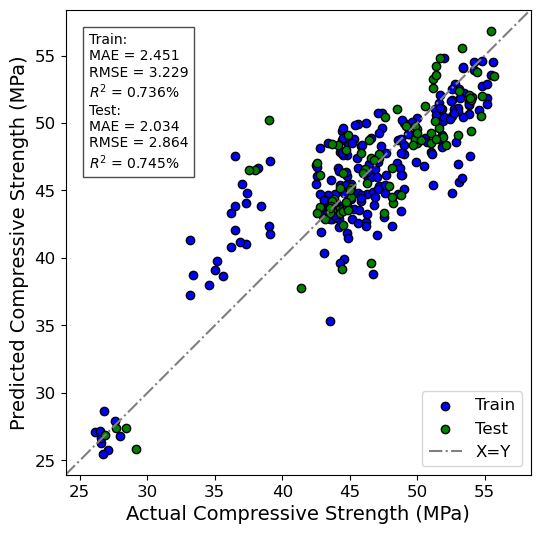

In [46]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_lr,
                            y_test_reg, y_test_pred_lr,
                            train_metrics_lr, test_metrics_lr,
                            colors=['blue', 'green'])

# KNN

In [62]:
# KNN optimization using Optuna
from sklearn.neighbors import KNeighborsRegressor
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors',1,31)
    weights = trial.suggest_categorical('weights', ["uniform","distance"])
    p = trial.suggest_int('p' , 1,3)
    metric = trial.suggest_categorical('metric' , ["minkowski"])
 
    
    model_opt_KNN = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p, metric=metric)
    
    score = cross_val_score(model_opt_KNN, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [60]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2026-02-25 11:36:42,857] A new study created in memory with name: no-name-6ac6ae19-1508-45ce-b223-7c01f911bb7c
[I 2026-02-25 11:36:49,249] Trial 0 finished with value: -3.07536842690403 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 3, 'metric': 'minkowski'}. Best is trial 0 with value: -3.07536842690403.
[I 2026-02-25 11:36:49,325] Trial 1 finished with value: -4.157214992116018 and parameters: {'n_neighbors': 25, 'weights': 'uniform', 'p': 1, 'metric': 'minkowski'}. Best is trial 0 with value: -3.07536842690403.
[I 2026-02-25 11:36:49,411] Trial 2 finished with value: -2.9978286223238713 and parameters: {'n_neighbors': 10, 'weights': 'distance', 'p': 2, 'metric': 'minkowski'}. Best is trial 2 with value: -2.9978286223238713.
[I 2026-02-25 11:36:49,485] Trial 3 finished with value: -3.1638164712453483 and parameters: {'n_neighbors': 1, 'weights': 'distance', 'p': 3, 'metric': 'minkowski'}. Best is trial 2 with value: -2.9978286223238713.
[I 2026-02-25 11:36:49,548]

Best hyperparameters found: {'n_neighbors': 6, 'weights': 'distance', 'p': 2, 'metric': 'minkowski'}


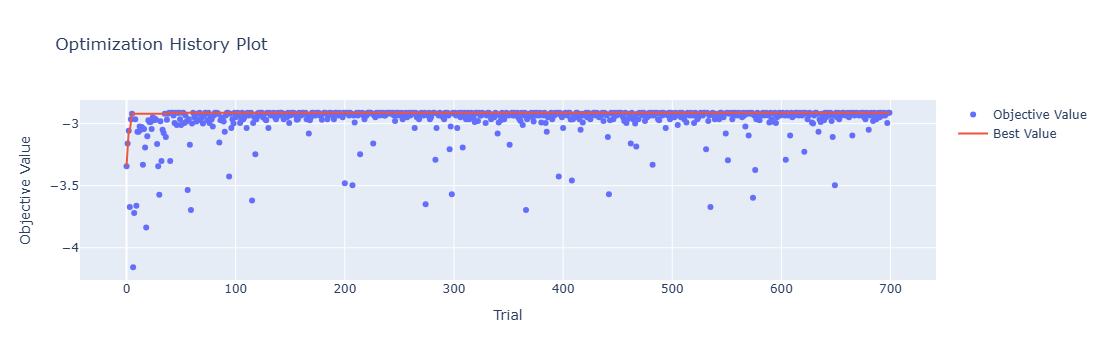

In [43]:
optuna.visualization.plot_optimization_history(study)

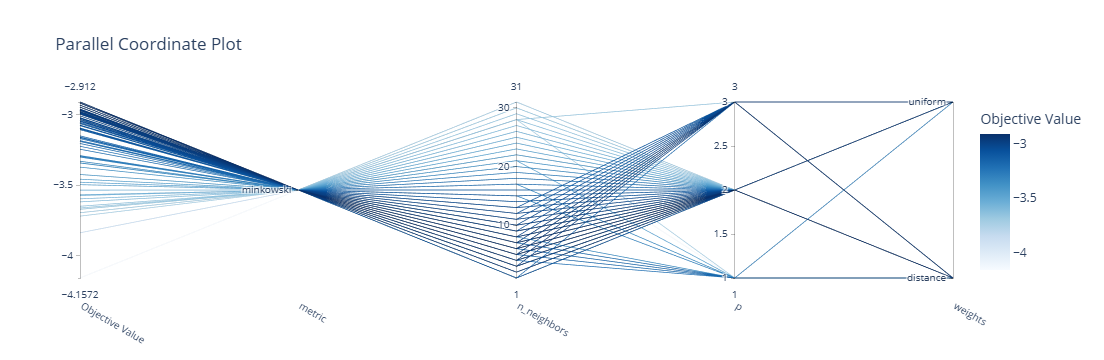

In [35]:
optuna.visualization.plot_parallel_coordinate(study)

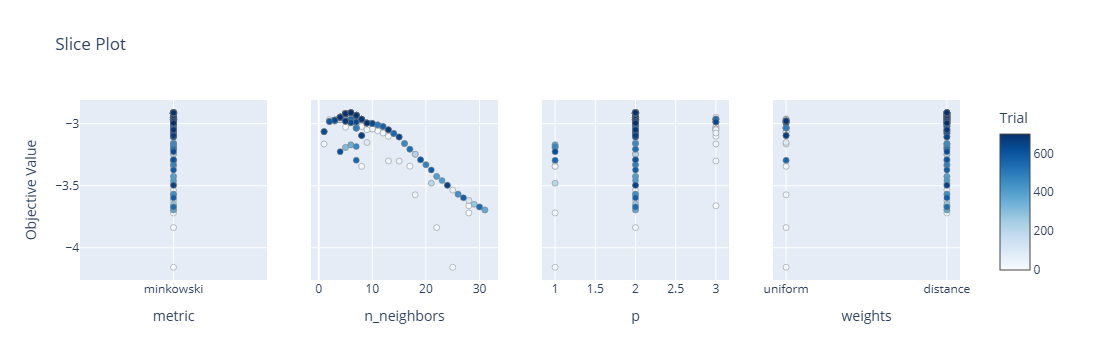

In [39]:
optuna.visualization.plot_slice(study, params=['n_neighbors', 'weights', 'p', 'metric'])

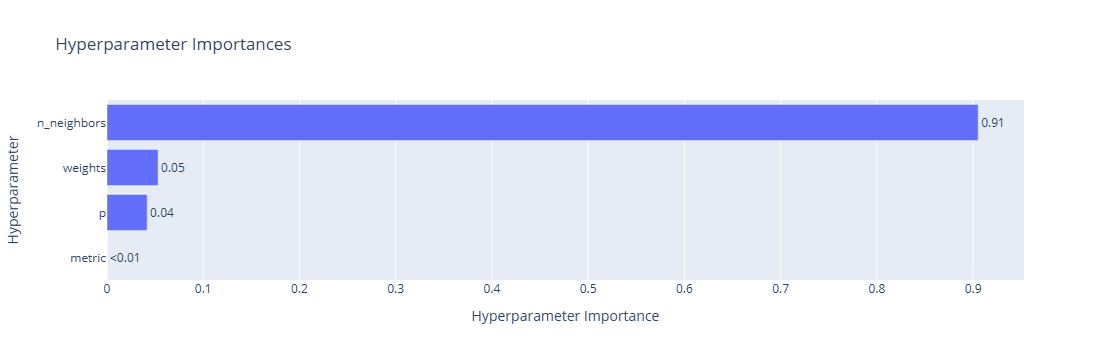

In [41]:
optuna.visualization.plot_param_importances(study)

In [64]:
#KNN modeling
from sklearn.neighbors import KNeighborsRegressor

KNN = KNeighborsRegressor(
    n_neighbors=6,
    metric='minkowski',
    p=2,
    weights='distance'
).fit(X_train_reg, y_train_reg)

In [66]:
# Making predictions
y_train_pred_KNN = KNN.predict(X_train_reg)
y_test_pred_KNN = KNN.predict(X_test_reg)
y_complete_pred_KNN = KNN.predict(X_reg)

train_metrics_KNN = evaluate_predictions(y_train_reg, y_train_pred_KNN)
test_metrics_KNN = evaluate_predictions(y_test_reg, y_test_pred_KNN)
complete_metrics_KNN = evaluate_predictions(y_reg, y_complete_pred_KNN)

# Printing the results
print_results(train_metrics_KNN , 'Train_KNN')
print_results(test_metrics_KNN , 'Test_KNN')
print_results(complete_metrics_KNN , 'Total dataset_KNN')

Train_KNN MAE = 0.0
Train_KNN MSE = 0.0
Train_KNN RMSE = 0.0
Train_KNN MAPE = 0.0%
Train_KNN R2 = 1.0%

Test_KNN MAE = 1.274
Test_KNN MSE = 2.578
Test_KNN RMSE = 1.606
Test_KNN MAPE = 0.027%
Test_KNN R2 = 0.92%

Total dataset_KNN MAE = 0.383
Total dataset_KNN MSE = 0.774
Total dataset_KNN RMSE = 0.88
Total dataset_KNN MAPE = 0.008%
Total dataset_KNN R2 = 0.979%



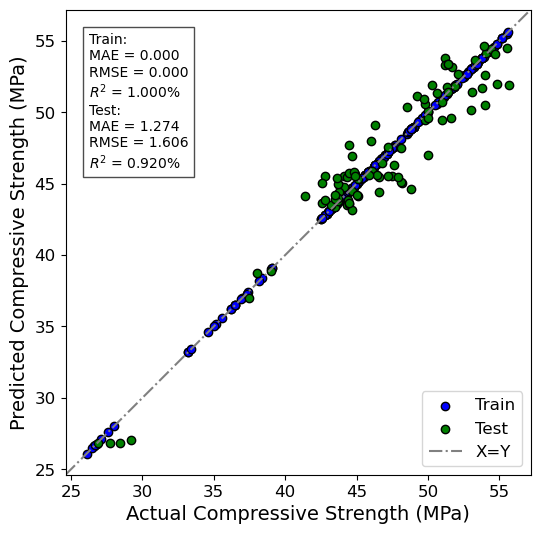

In [68]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_KNN,
                            y_test_reg, y_test_pred_KNN,
                            train_metrics_KNN, test_metrics_KNN,
                            colors=['blue', 'green'])

# SVM

In [70]:
# SVM optimization using Optuna
def objective(trial):
    C = trial.suggest_float('C',0.1,100,step=1)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'sigmoid', 'rbf'])
    gamma = trial.suggest_categorical('gamma' , ["scale","auto"])
 
    
    model_opt_SVR = SVR(C=C, kernel=kernel, gamma=gamma)
    
    score = cross_val_score(model_opt_SVR, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [46]:

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 11:44:14,206] A new study created in memory with name: no-name-c31fa5c9-c751-485c-8467-033962feed5d
E:\Anaconda\Lib\site-packages\optuna\distributions.py:684: UserWarning: The distribution is specified by [0.1, 100] and step=1, but the range is not divisible by `step`. It will be replaced by [0.1, 99.1].
  warnings.warn(
[I 2025-06-08 11:44:14,567] Trial 0 finished with value: -4.347250033822922 and parameters: {'C': 52.1, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 0 with value: -4.347250033822922.
[I 2025-06-08 11:44:14,752] Trial 1 finished with value: -6.8829584648494855 and parameters: {'C': 5.1, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: -4.347250033822922.
[I 2025-06-08 11:44:14,909] Trial 2 finished with value: -8.743906103772499 and parameters: {'C': 8.1, 'kernel': 'sigmoid', 'gamma': 'scale'}. Best is trial 0 with value: -4.347250033822922.
[I 2025-06-08 11:44:17,550] Trial 3 finished with value: -3.256116273106495 and parameters

Best hyperparameters found: {'C': 7.1, 'kernel': 'poly', 'gamma': 'scale'}


In [76]:
#SVM modeling
from sklearn.svm import SVR

# Create the SVR model with optimized parameters
svr = SVR(
    C=7.1,
    kernel='poly',
    gamma ='scale'
).fit(X_train_reg, y_train_reg)

In [74]:
# Making predictions
y_train_pred_svr = svr.predict(X_train_reg)
y_test_pred_svr = svr.predict(X_test_reg)
y_complete_pred_svr = svr.predict(X_reg)

train_metrics_svr = evaluate_predictions(y_train_reg, y_train_pred_svr)
test_metrics_svr = evaluate_predictions(y_test_reg, y_test_pred_svr)
complete_metrics_svr = evaluate_predictions(y_reg, y_complete_pred_svr)

# Printing the results
print_results(train_metrics_svr , 'Train_svr')
print_results(test_metrics_svr , 'Test_svr')
print_results(complete_metrics_svr , 'Complete dataset_svr')

Train_svr MAE = 1.172
Train_svr MSE = 3.155
Train_svr RMSE = 1.776
Train_svr MAPE = 0.027%
Train_svr R2 = 0.92%

Test_svr MAE = 1.401
Test_svr MSE = 3.538
Test_svr RMSE = 1.881
Test_svr MAPE = 0.031%
Test_svr R2 = 0.89%

Complete dataset_svr MAE = 1.241
Complete dataset_svr MSE = 3.27
Complete dataset_svr RMSE = 1.808
Complete dataset_svr MAPE = 0.028%
Complete dataset_svr R2 = 0.913%



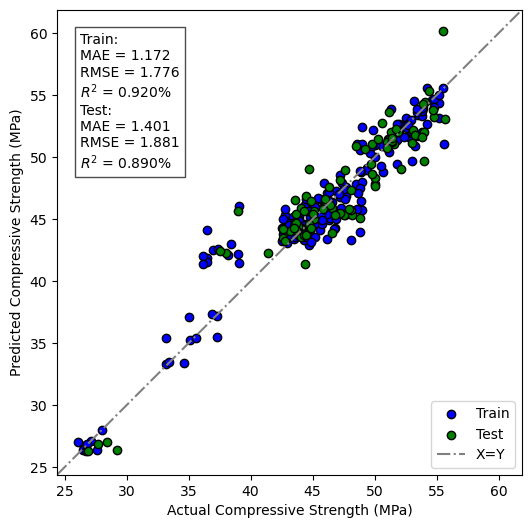

In [54]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_svr,
                            y_test_reg, y_test_pred_svr,
                            train_metrics_svr, test_metrics_svr,
                            colors=['blue', 'green'])

# DT

In [78]:
# DT optimization using Optuna
def objective(trial):
    criterion = trial.suggest_categorical('criterion',['squared_error', 'friedman_mse', 'absolute_error'])
    max_depth = trial.suggest_int('max_depth', 2,50)
    min_samples_split = trial.suggest_int('min_samples_split' , 2,20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf' , 1,20)
 
    
    model_opt_DT = DecisionTreeRegressor(criterion=criterion, max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
    
    score = cross_val_score(model_opt_DT, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [61]:

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 11:50:50,117] A new study created in memory with name: no-name-e5413200-4c87-4bb9-a2cd-05c8a88ed210
[I 2025-06-08 11:50:50,331] Trial 0 finished with value: -4.300128602968063 and parameters: {'criterion': 'friedman_mse', 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 12}. Best is trial 0 with value: -4.300128602968063.
[I 2025-06-08 11:50:50,467] Trial 1 finished with value: -4.417697930773824 and parameters: {'criterion': 'squared_error', 'max_depth': 11, 'min_samples_split': 17, 'min_samples_leaf': 18}. Best is trial 0 with value: -4.300128602968063.
[I 2025-06-08 11:50:50,569] Trial 2 finished with value: -4.196910369072155 and parameters: {'criterion': 'friedman_mse', 'max_depth': 12, 'min_samples_split': 11, 'min_samples_leaf': 13}. Best is trial 2 with value: -4.196910369072155.
[I 2025-06-08 11:50:50,686] Trial 3 finished with value: -3.7494609019577467 and parameters: {'criterion': 'friedman_mse', 'max_depth': 42, 'min_samples_split': 17, 'min_sampl

Best hyperparameters found: {'criterion': 'absolute_error', 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 5}


In [63]:
#IN this block after understanding the best hyperparameters, they will use to make predictions based on it
from sklearn.tree import DecisionTreeRegressor

# Create the Decision Tree Regressor model with optimized parameters
dt = DecisionTreeRegressor(
    criterion='absolute_error',
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=3
).fit(X_train_reg, y_train_reg)

In [65]:
# Making predictions
y_train_pred_dt0 = dt.predict(X_train_reg)
y_test_pred_dt0 = dt.predict(X_test_reg)
y_complete_pred_dt0 = dt.predict(X_reg)

train_metrics_dt0 = evaluate_predictions(y_train_reg, y_train_pred_dt0)
test_metrics_dt0 = evaluate_predictions(y_test_reg, y_test_pred_dt0)
complete_metrics_dt0 = evaluate_predictions(y_reg, y_complete_pred_dt0)

# Printing the results
print_results(train_metrics_dt0 , 'Train_dt')
print_results(test_metrics_dt0 , 'Test_dt')
print_results(complete_metrics_dt0 , 'Complete dataset_dt')

Train_dt MAE = 2.161
Train_dt MSE = 9.275
Train_dt RMSE = 3.045
Train_dt MAPE = 0.048%
Train_dt R2 = 0.765%

Test_dt MAE = 1.815
Test_dt MSE = 6.254
Test_dt RMSE = 2.501
Test_dt MAPE = 0.04%
Test_dt R2 = 0.805%

Complete dataset_dt MAE = 2.057
Complete dataset_dt MSE = 8.368
Complete dataset_dt RMSE = 2.893
Complete dataset_dt MAPE = 0.046%
Complete dataset_dt R2 = 0.777%



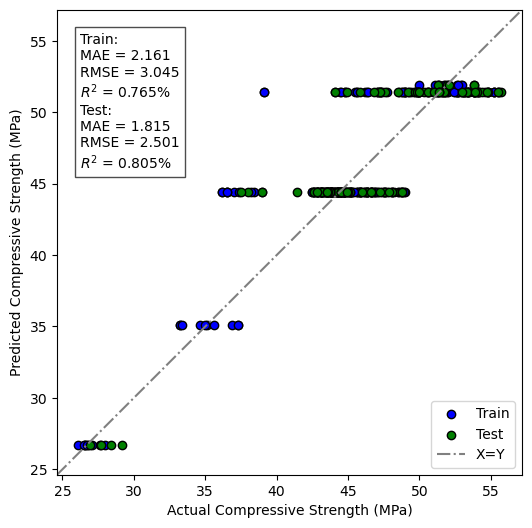

In [67]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_dt0,
                            y_test_reg, y_test_pred_dt0,
                            train_metrics_dt0, test_metrics_dt0,
                            colors=['blue', 'green'])

# RF

In [82]:
# RF OPtimization using Optuna
def objective(trial):

    max_depth = trial.suggest_int('max_depth', 2,15)
    n_estimators = trial.suggest_int('n_estimators' , 2,100)

 
    
    model_opt_RF = RandomForestRegressor(max_depth=max_depth, n_estimators=n_estimators)
    
    score = cross_val_score(model_opt_RF, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [73]:
from optuna.samplers import RandomSampler
study = optuna.create_study(direction="maximize", sampler=RandomSampler())
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 11:55:20,044] A new study created in memory with name: no-name-d79fdc2c-781c-4137-b9d5-fce4b4a741f8
[I 2025-06-08 11:55:22,540] Trial 0 finished with value: -3.3504260103922965 and parameters: {'max_depth': 12, 'n_estimators': 78}. Best is trial 0 with value: -3.3504260103922965.
[I 2025-06-08 11:55:22,752] Trial 1 finished with value: -3.2247766321420057 and parameters: {'max_depth': 8, 'n_estimators': 6}. Best is trial 1 with value: -3.2247766321420057.
[I 2025-06-08 11:55:25,510] Trial 2 finished with value: -3.3537771576331172 and parameters: {'max_depth': 15, 'n_estimators': 98}. Best is trial 1 with value: -3.2247766321420057.
[I 2025-06-08 11:55:25,698] Trial 3 finished with value: -3.5436850042949737 and parameters: {'max_depth': 10, 'n_estimators': 4}. Best is trial 1 with value: -3.2247766321420057.
[I 2025-06-08 11:55:26,495] Trial 4 finished with value: -3.4077421134092356 and parameters: {'max_depth': 10, 'n_estimators': 24}. Best is trial 1 with value: -3.22

Best hyperparameters found: {'max_depth': 12, 'n_estimators': 7}


In [75]:
#RF
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest Regressor model with optimized parameters
rf = RandomForestRegressor(
    max_depth=12,
    n_estimators=7).fit(X_train_reg, y_train_reg)

In [77]:
# Making predictions
y_train_pred_rf0 = rf.predict(X_train_reg)
y_test_pred_rf0 = rf.predict(X_test_reg)
y_complete_pred_rf0 = rf.predict(X_reg)

train_metrics_rf0 = evaluate_predictions(y_train_reg, y_train_pred_rf0)
test_metrics_rf0 = evaluate_predictions(y_test_reg, y_test_pred_rf0)
complete_metrics_rf0 = evaluate_predictions(y_reg, y_complete_pred_rf0)

# Printing the results
print_results(train_metrics_rf0 , 'Train_rf')
print_results(test_metrics_rf0 , 'Test_rf')
print_results(complete_metrics_rf0 , 'Complete dataset_rf')

Train_rf MAE = 0.675
Train_rf MSE = 1.023
Train_rf RMSE = 1.012
Train_rf MAPE = 0.015%
Train_rf R2 = 0.974%

Test_rf MAE = 1.49
Test_rf MSE = 4.037
Test_rf RMSE = 2.009
Test_rf MAPE = 0.032%
Test_rf R2 = 0.874%

Complete dataset_rf MAE = 0.92
Complete dataset_rf MSE = 1.928
Complete dataset_rf RMSE = 1.389
Complete dataset_rf MAPE = 0.02%
Complete dataset_rf R2 = 0.949%



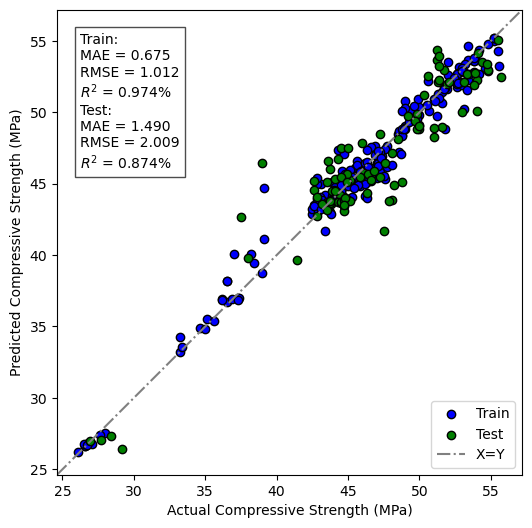

In [79]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_rf0,
                            y_test_reg, y_test_pred_rf0,
                            train_metrics_rf0, test_metrics_rf0,
                            colors=['blue', 'green'])

# ET

In [86]:
# ET optimization using Optuna
def objective(trial):

    max_depth = trial.suggest_int('max_depth', 2,15)
    n_estimators = trial.suggest_int('n_estimators' , 2,100)

 
    
    model_opt_ET = RandomForestRegressor(max_depth=max_depth, n_estimators=n_estimators)
    
    score = cross_val_score(model_opt_ET, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [85]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 12:13:15,750] A new study created in memory with name: no-name-5dd61fb9-760a-42a2-b2ca-3ce0ff7c9e6e
[I 2025-06-08 12:13:16,245] Trial 0 finished with value: -3.566879096646319 and parameters: {'max_depth': 6, 'n_estimators': 11}. Best is trial 0 with value: -3.566879096646319.
[I 2025-06-08 12:13:16,602] Trial 1 finished with value: -3.360641253969031 and parameters: {'max_depth': 11, 'n_estimators': 8}. Best is trial 1 with value: -3.360641253969031.
[I 2025-06-08 12:13:18,674] Trial 2 finished with value: -3.2608706833069028 and parameters: {'max_depth': 14, 'n_estimators': 68}. Best is trial 2 with value: -3.2608706833069028.
[I 2025-06-08 12:13:19,126] Trial 3 finished with value: -3.4472725532799977 and parameters: {'max_depth': 8, 'n_estimators': 16}. Best is trial 2 with value: -3.2608706833069028.
[I 2025-06-08 12:13:19,951] Trial 4 finished with value: -3.3680073120466836 and parameters: {'max_depth': 14, 'n_estimators': 27}. Best is trial 2 with value: -3.260870

Best hyperparameters found: {'max_depth': 12, 'n_estimators': 7}


In [87]:
from sklearn.ensemble import ExtraTreesRegressor

# Create the Extra Trees Regressor model with optimized parameters
best_extra_trees = ExtraTreesRegressor(
    max_depth=12,
    n_estimators=7,
).fit(X_train_reg, y_train_reg)

In [89]:
# Making predictions
y_train_pred_extra_trees = best_extra_trees.predict(X_train_reg)
y_test_pred_extra_trees = best_extra_trees.predict(X_test_reg)
y_complete_pred_extra_trees = best_extra_trees.predict(X_reg)

train_metrics_extra_trees = evaluate_predictions(y_train_reg, y_train_pred_extra_trees)
test_metrics_extra_trees = evaluate_predictions(y_test_reg, y_test_pred_extra_trees)
complete_metrics_extra_trees = evaluate_predictions(y_reg, y_complete_pred_extra_trees)

# Printing the results
print_results(train_metrics_extra_trees , 'Train_extra_trees')
print_results(test_metrics_extra_trees , 'Test_extra_trees')
print_results(complete_metrics_extra_trees , 'Complete dataset_extra_trees')

Train_extra_trees MAE = 0.178
Train_extra_trees MSE = 0.103
Train_extra_trees RMSE = 0.321
Train_extra_trees MAPE = 0.004%
Train_extra_trees R2 = 0.997%

Test_extra_trees MAE = 1.344
Test_extra_trees MSE = 2.92
Test_extra_trees RMSE = 1.709
Test_extra_trees MAPE = 0.029%
Test_extra_trees R2 = 0.909%

Complete dataset_extra_trees MAE = 0.528
Complete dataset_extra_trees MSE = 0.949
Complete dataset_extra_trees RMSE = 0.974
Complete dataset_extra_trees MAPE = 0.011%
Complete dataset_extra_trees R2 = 0.975%



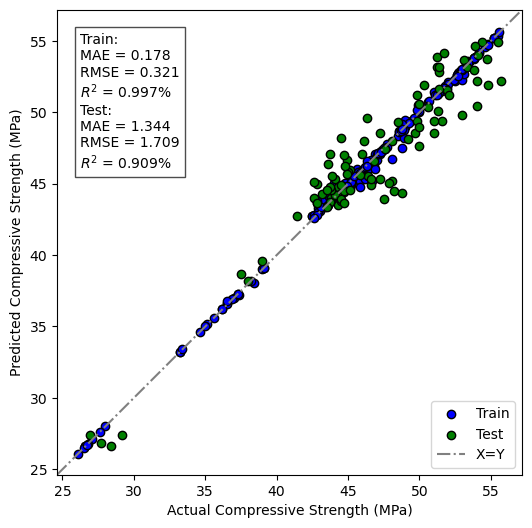

In [91]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_extra_trees,
                            y_test_reg, y_test_pred_extra_trees,
                            train_metrics_extra_trees, test_metrics_extra_trees,
                            colors=['blue', 'green'])

# AdaBoost

In [88]:
# Adaboost optimization using Optuna
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 2, 100) 
    learning_rate = trial.suggest_float('learning_rate', 0.1, 2)  # Fixed colon to =
    
    # Hyperparameters for DecisionTreeRegressor
    max_depth = trial.suggest_int('estimator__max_depth', 2, 15)  # Fixed colon to =
    
    model_opt_Ada = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=max_depth),
        n_estimators=n_estimators,
        learning_rate=learning_rate
    )
    
    score = cross_val_score(model_opt_Ada, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    return score

In [97]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 12:28:22,946] A new study created in memory with name: no-name-ed0e29d0-528e-4e9f-a463-cabf14cc3669
[I 2025-06-08 12:28:24,773] Trial 0 finished with value: -2.974692436976825 and parameters: {'n_estimators': 58, 'learning_rate': 1.3338983276077312, 'estimator__max_depth': 11}. Best is trial 0 with value: -2.974692436976825.
[I 2025-06-08 12:28:24,914] Trial 1 finished with value: -4.460934240261013 and parameters: {'n_estimators': 2, 'learning_rate': 1.7119034595933065, 'estimator__max_depth': 14}. Best is trial 0 with value: -2.974692436976825.
[I 2025-06-08 12:28:27,524] Trial 2 finished with value: -2.9922971213932668 and parameters: {'n_estimators': 96, 'learning_rate': 1.4839168524848878, 'estimator__max_depth': 9}. Best is trial 0 with value: -2.974692436976825.
[I 2025-06-08 12:28:27,670] Trial 3 finished with value: -3.5589101051465484 and parameters: {'n_estimators': 3, 'learning_rate': 0.12847993670275898, 'estimator__max_depth': 5}. Best is trial 0 with value:

Best hyperparameters found: {'n_estimators': 74, 'learning_rate': 1.6320950399222907, 'estimator__max_depth': 9}


In [94]:
# Adaboost modeling
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Create the AdaBoost model with optimized parameters
best_adaboost = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=9,
    ),
    #learning_rate=0.7,
    #n_estimators=12
    learning_rate=1.6320950399222907,
    n_estimators=74
).fit(X_train_reg, y_train_reg)

In [101]:
# Making predictions
y_train_pred_adaboost = best_adaboost.predict(X_train_reg)
y_test_pred_adaboost = best_adaboost.predict(X_test_reg)
y_complete_pred_adaboost = best_adaboost.predict(X_reg)

# Evaluating the model
train_metrics_adaboost = evaluate_predictions(y_train_reg, y_train_pred_adaboost)
test_metrics_adaboost = evaluate_predictions(y_test_reg, y_test_pred_adaboost)
complete_metrics_adaboost = evaluate_predictions(y_reg, y_complete_pred_adaboost)

# Printing the results
print_results(train_metrics_adaboost, 'Train adaboost')
print_results(test_metrics_adaboost, 'Test adaboost')
print_results(complete_metrics_adaboost, 'Complete dataset adaboost')

Train adaboost MAE = 0.511
Train adaboost MSE = 0.62
Train adaboost RMSE = 0.787
Train adaboost MAPE = 0.011%
Train adaboost R2 = 0.984%

Test adaboost MAE = 1.33
Test adaboost MSE = 2.997
Test adaboost RMSE = 1.731
Test adaboost MAPE = 0.028%
Test adaboost R2 = 0.907%

Complete dataset adaboost MAE = 0.757
Complete dataset adaboost MSE = 1.334
Complete dataset adaboost RMSE = 1.155
Complete dataset adaboost MAPE = 0.016%
Complete dataset adaboost R2 = 0.964%



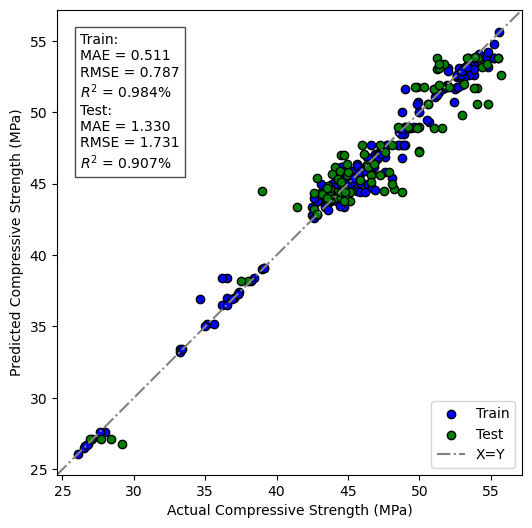

In [103]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_adaboost,
                            y_test_reg, y_test_pred_adaboost,
                            train_metrics_adaboost, test_metrics_adaboost,
                            colors=['blue', 'green'])

# GBM

In [90]:
# GBM optimization using Optuna
from sklearn.ensemble import GradientBoostingRegressor
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 2, 100) 
    learning_rate = trial.suggest_float('learning_rate', 0.1, 2)  # Fixed colon to =
    max_depth = trial.suggest_int('max_depth', 2, 15)  # Fixed colon to =
    
    model_opt_GBM = GradientBoostingRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth
    )
    
    score = cross_val_score(model_opt_GBM, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    return score

In [108]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 12:59:03,435] A new study created in memory with name: no-name-3ea0fa03-341b-49c3-ac24-4085d695fe7b
[I 2025-06-08 12:59:25,621] Trial 0 finished with value: -4.091597310571823 and parameters: {'n_estimators': 3, 'learning_rate': 0.12593040734795177, 'max_depth': 10}. Best is trial 0 with value: -4.091597310571823.
[I 2025-06-08 12:59:26,610] Trial 1 finished with value: -3.214159512543296 and parameters: {'n_estimators': 34, 'learning_rate': 0.37575419770576257, 'max_depth': 11}. Best is trial 1 with value: -3.214159512543296.
[I 2025-06-08 12:59:27,444] Trial 2 finished with value: -3.8857340764337094 and parameters: {'n_estimators': 52, 'learning_rate': 1.073517556710963, 'max_depth': 4}. Best is trial 1 with value: -3.214159512543296.
[I 2025-06-08 12:59:28,657] Trial 3 finished with value: -4.521138069973958 and parameters: {'n_estimators': 45, 'learning_rate': 1.5699101704084797, 'max_depth': 8}. Best is trial 1 with value: -3.214159512543296.
[I 2025-06-08 12:59:29,

Best hyperparameters found: {'n_estimators': 71, 'learning_rate': 0.6007468823390762, 'max_depth': 2}


In [92]:
# GBM modeling
from sklearn.ensemble import GradientBoostingRegressor

# Create the Gradient Boosting Regressor model with optimized parameters
best_gbm = GradientBoostingRegressor(
    learning_rate=0.6007468823390762,
    max_depth=2,
    n_estimators=71,
).fit(X_train_reg, y_train_reg)

In [111]:
# Making predictions
y_train_pred_gbm = best_gbm.predict(X_train_reg)
y_test_pred_gbm = best_gbm.predict(X_test_reg)
y_complete_pred_gbm = best_gbm.predict(X_reg)

# Evaluating the model
train_metrics_gbm = evaluate_predictions(y_train_reg, y_train_pred_gbm)
test_metrics_gbm = evaluate_predictions(y_test_reg, y_test_pred_gbm)
complete_metrics_gbm = evaluate_predictions(y_reg, y_complete_pred_gbm)

# Printing the results
print_results(train_metrics_gbm, 'Train gbm')
print_results(test_metrics_gbm, 'Test gbm')
print_results(complete_metrics_gbm, 'Complete dataset gbm')

Train gbm MAE = 0.323
Train gbm MSE = 0.173
Train gbm RMSE = 0.416
Train gbm MAPE = 0.007%
Train gbm R2 = 0.996%

Test gbm MAE = 1.728
Test gbm MSE = 4.825
Test gbm RMSE = 2.197
Test gbm MAPE = 0.038%
Test gbm R2 = 0.85%

Complete dataset gbm MAE = 0.745
Complete dataset gbm MSE = 1.57
Complete dataset gbm RMSE = 1.253
Complete dataset gbm MAPE = 0.016%
Complete dataset gbm R2 = 0.958%



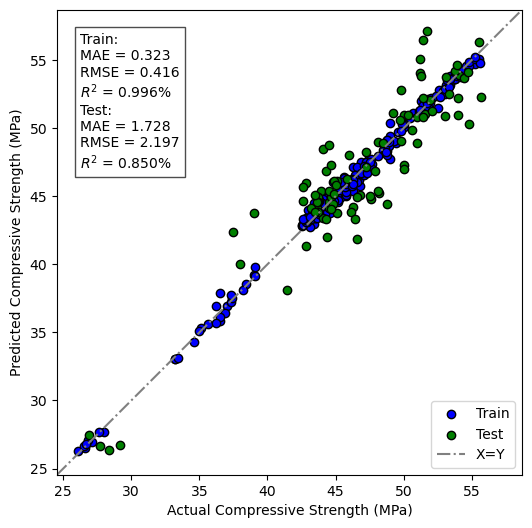

In [114]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_gbm,
                            y_test_reg, y_test_pred_gbm,
                            train_metrics_gbm, test_metrics_gbm,
                            colors=['blue', 'green'])

# XGB

In [96]:
# XGB optimization using Optuna
import xgboost as xgb
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators',10,500,step=5)
    max_depth = trial.suggest_int('max_depth', 2,15)
    subsample = trial.suggest_float('subsample', 0.1, 0.9, step=0.05)
    gamma = trial.suggest_float('gamma' ,0.1, 0.9, step=0.05)
    reg_lambda = trial.suggest_float('reg_lambda', 0.1, 0.9, step=0.05)
    alpha = trial.suggest_float('alpha', 0.1, 0.9, step=0.05) 
    
    model_opt_xgb = xgb.XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, subsample=subsample, gamma=gamma, reg_lambda=reg_lambda, alpha=alpha)
    
    score = cross_val_score(model_opt_xgb, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [122]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 13:28:38,853] A new study created in memory with name: no-name-57c3c4b6-8216-4353-be97-7eef55f56405
[I 2025-06-08 13:28:50,680] Trial 0 finished with value: -3.5398287430665105 and parameters: {'n_estimators': 200, 'max_depth': 14, 'subsample': 0.85, 'gamma': 0.55, 'reg_lambda': 0.8, 'alpha': 0.5}. Best is trial 0 with value: -3.5398287430665105.
[I 2025-06-08 13:28:51,444] Trial 1 finished with value: -3.056162553167649 and parameters: {'n_estimators': 235, 'max_depth': 2, 'subsample': 0.7000000000000001, 'gamma': 0.15000000000000002, 'reg_lambda': 0.55, 'alpha': 0.30000000000000004}. Best is trial 1 with value: -3.056162553167649.
[I 2025-06-08 13:28:51,966] Trial 2 finished with value: -3.6001361620770993 and parameters: {'n_estimators': 105, 'max_depth': 3, 'subsample': 0.2, 'gamma': 0.30000000000000004, 'reg_lambda': 0.65, 'alpha': 0.1}. Best is trial 1 with value: -3.056162553167649.
[I 2025-06-08 13:28:53,256] Trial 3 finished with value: -3.645583086760767 and par

Best hyperparameters found: {'n_estimators': 120, 'max_depth': 2, 'subsample': 0.35, 'gamma': 0.35, 'reg_lambda': 0.25, 'alpha': 0.75}


In [98]:
# XGB modeling
from xgboost import XGBRegressor

# Create the XGBoost Regressor model with optimized parameters
xgb0 = XGBRegressor(
    max_depth=2,
    n_estimators=120,
    reg_lambda= 0.25,
    gamma = 0.35,
    subsample=0.35,
    alpha = 0.75
).fit(X_train_reg, y_train_reg)

In [126]:
# Making predictions
y_train_pred_xgb0 = xgb0.predict(X_train_reg)
y_test_pred_xgb0 = xgb0.predict(X_test_reg)
y_complete_pred_xgb0 = xgb0.predict(X_reg)

# Evaluating the model
train_metrics_xgb0 = evaluate_predictions(y_train_reg, y_train_pred_xgb0)
test_metrics_xgb0 = evaluate_predictions(y_test_reg, y_test_pred_xgb0)
complete_metrics_xgb0 = evaluate_predictions(y_reg, y_complete_pred_xgb0)

# Printing the results
print_results(train_metrics_xgb0, 'Train xgb')
print_results(test_metrics_xgb0, 'Test xgb')
print_results(complete_metrics_xgb0, 'Complete dataset xgb')

Train xgb MAE = 0.598
Train xgb MSE = 0.585
Train xgb RMSE = 0.765
Train xgb MAPE = 0.014%
Train xgb R2 = 0.985%

Test xgb MAE = 1.679
Test xgb MSE = 4.298
Test xgb RMSE = 2.073
Test xgb MAPE = 0.036%
Test xgb R2 = 0.866%

Complete dataset xgb MAE = 0.923
Complete dataset xgb MSE = 1.7
Complete dataset xgb RMSE = 1.304
Complete dataset xgb MAPE = 0.02%
Complete dataset xgb R2 = 0.955%



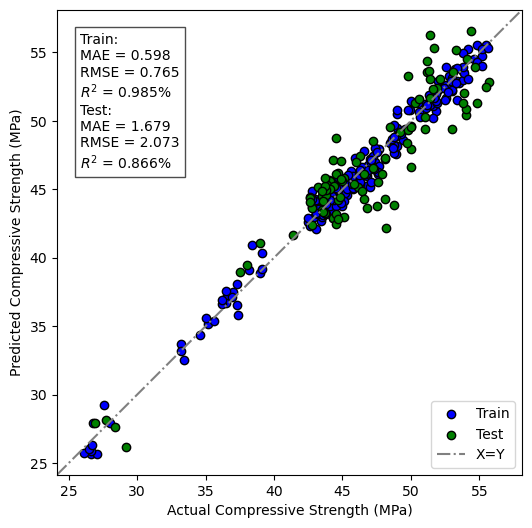

In [128]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_xgb0,
                            y_test_reg, y_test_pred_xgb0,
                            train_metrics_xgb0, test_metrics_xgb0,
                            colors=['blue', 'green'])

# LGBM

In [100]:
# LGBM optimization using Optuna
from lightgbm import LGBMRegressor
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators',10,500,step=5)
    num_leaves = trial.suggest_int('num_leaves', 10,300)
    learning_rate = trial.suggest_float('learning_rate', 0.1, 0.9, step=0.05)
    reg_lambda = trial.suggest_float('reg_lambda', 0.1, 0.9, step=0.05)
    reg_alpha = trial.suggest_float('reg_alpha', 0.1, 0.9, step=0.05) 
    
    model_opt_LGBM = LGBMRegressor(n_estimators=n_estimators, num_leaves=num_leaves, 
                                   learning_rate=learning_rate, reg_lambda=reg_lambda, reg_alpha=reg_alpha)
    
    score = cross_val_score(model_opt_LGBM, X_reg, y_reg, n_jobs=-1, cv=10, scoring='neg_mean_absolute_error').mean()
    
    return score

In [131]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=700)

print("Best hyperparameters found:", study.best_params)

[I 2025-06-08 13:41:46,587] A new study created in memory with name: no-name-28f63967-1394-4238-921f-16705ce0c8fa
[I 2025-06-08 13:42:01,109] Trial 0 finished with value: -3.3669578632786648 and parameters: {'n_estimators': 155, 'num_leaves': 236, 'learning_rate': 0.85, 'reg_lambda': 0.75, 'reg_alpha': 0.85}. Best is trial 0 with value: -3.3669578632786648.
[I 2025-06-08 13:42:01,738] Trial 1 finished with value: -3.447722182672142 and parameters: {'n_estimators': 180, 'num_leaves': 173, 'learning_rate': 0.45000000000000007, 'reg_lambda': 0.85, 'reg_alpha': 0.9}. Best is trial 0 with value: -3.3669578632786648.
[I 2025-06-08 13:42:02,048] Trial 2 finished with value: -3.3306437681085983 and parameters: {'n_estimators': 60, 'num_leaves': 44, 'learning_rate': 0.45000000000000007, 'reg_lambda': 0.5, 'reg_alpha': 0.75}. Best is trial 2 with value: -3.3306437681085983.
[I 2025-06-08 13:42:02,824] Trial 3 finished with value: -3.5292936898111975 and parameters: {'n_estimators': 205, 'num_lea

Best hyperparameters found: {'n_estimators': 235, 'num_leaves': 114, 'learning_rate': 0.35, 'reg_lambda': 0.8, 'reg_alpha': 0.25}


In [102]:
# LGBM modeling
from lightgbm import LGBMRegressor

# Fit the model
lgbm_reg0 = LGBMRegressor(
    reg_lambda= 0.8,
    reg_alpha= 0.25,
    num_leaves= 114,
    n_estimators= 235,
    learning_rate= 0.35,
).fit(X_train_reg, y_train_reg)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002568 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 563
[LightGBM] [Info] Number of data points in the train set: 219, number of used features: 11
[LightGBM] [Info] Start training from score 45.754947
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [136]:
# Predict
y_train_pred_lgbm0 = lgbm_reg0.predict(X_train_reg)
y_test_pred_lgbm0 = lgbm_reg0.predict(X_test_reg)
y_complete_pred_lgbm0 = lgbm_reg0.predict(X_reg)

# Evaluate the model
train_metrics_lgbm0 = evaluate_predictions(y_train_reg, y_train_pred_lgbm0)
test_metrics_lgbm0 = evaluate_predictions(y_test_reg, y_test_pred_lgbm0)
complete_metrics_lgbm0 = evaluate_predictions(y_reg, y_complete_pred_lgbm0)

# Print results
print_results(train_metrics_lgbm0, 'Train lgbm')
print_results(test_metrics_lgbm0, 'Test lgbm')
print_results(complete_metrics_lgbm0, 'Complete dataset lgbm')

Train lgbm MAE = 0.102
Train lgbm MSE = 0.022
Train lgbm RMSE = 0.148
Train lgbm MAPE = 0.002%
Train lgbm R2 = 0.999%

Test lgbm MAE = 1.805
Test lgbm MSE = 5.563
Test lgbm RMSE = 2.359
Test lgbm MAPE = 0.039%
Test lgbm R2 = 0.827%

Complete dataset lgbm MAE = 0.613
Complete dataset lgbm MSE = 1.686
Complete dataset lgbm RMSE = 1.298
Complete dataset lgbm MAPE = 0.013%
Complete dataset lgbm R2 = 0.955%



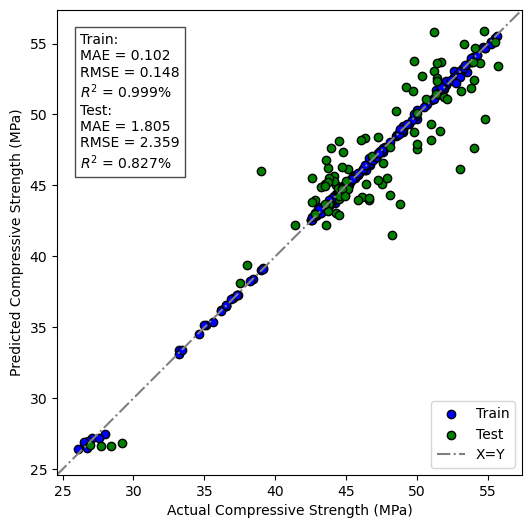

In [138]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_lgbm0,
                            y_test_reg, y_test_pred_lgbm0,
                            train_metrics_lgbm0, test_metrics_lgbm0,
                            colors=['blue', 'green'])

# CatBoost

In [104]:
# CatBoost modeling without optimizing as it has the ability to optimize itself
from catboost import CatBoostRegressor

cat_reg = CatBoostRegressor(random_seed=RANDOM_SEED)

cat_reg.fit(X_train_reg, y_train_reg)

Learning rate set to 0.032208
0:	learn: 6.1722472	total: 195ms	remaining: 3m 14s
1:	learn: 6.0715954	total: 206ms	remaining: 1m 42s
2:	learn: 5.9486323	total: 214ms	remaining: 1m 11s
3:	learn: 5.8470177	total: 217ms	remaining: 54.1s
4:	learn: 5.7420665	total: 220ms	remaining: 43.7s
5:	learn: 5.6354826	total: 222ms	remaining: 36.8s
6:	learn: 5.5454835	total: 225ms	remaining: 31.9s
7:	learn: 5.4424494	total: 229ms	remaining: 28.4s
8:	learn: 5.3468544	total: 232ms	remaining: 25.5s
9:	learn: 5.2682909	total: 234ms	remaining: 23.2s
10:	learn: 5.1678085	total: 237ms	remaining: 21.3s
11:	learn: 5.0922825	total: 240ms	remaining: 19.7s
12:	learn: 5.0016902	total: 243ms	remaining: 18.4s
13:	learn: 4.9155302	total: 244ms	remaining: 17.2s
14:	learn: 4.8499427	total: 246ms	remaining: 16.2s
15:	learn: 4.7664814	total: 248ms	remaining: 15.2s
16:	learn: 4.6975353	total: 250ms	remaining: 14.4s
17:	learn: 4.6217058	total: 251ms	remaining: 13.7s
18:	learn: 4.5637643	total: 253ms	remaining: 13.1s
19:	lear

In [142]:
# Predict
y_train_pred_cat_reg = cat_reg.predict(X_train_reg)
y_test_pred_cat_reg = cat_reg.predict(X_test_reg)
y_complete_pred_cat_reg = cat_reg.predict(X_reg)

# Evaluate the model
train_metrics_cat_reg = evaluate_predictions(y_train_reg, y_train_pred_cat_reg)
test_metrics_cat_reg = evaluate_predictions(y_test_reg, y_test_pred_cat_reg)
complete_metrics_cat_reg = evaluate_predictions(y_reg, y_complete_pred_cat_reg)

# Print results
print_results(train_metrics_cat_reg, 'Train cat_reg')
print_results(test_metrics_cat_reg, 'Test cat_reg')
print_results(complete_metrics_cat_reg, 'Complete dataset cat_reg')

Train cat_reg MAE = 0.179
Train cat_reg MSE = 0.048
Train cat_reg RMSE = 0.22
Train cat_reg MAPE = 0.004%
Train cat_reg R2 = 0.999%

Test cat_reg MAE = 1.27
Test cat_reg MSE = 2.676
Test cat_reg RMSE = 1.636
Test cat_reg MAPE = 0.027%
Test cat_reg R2 = 0.917%

Complete dataset cat_reg MAE = 0.506
Complete dataset cat_reg MSE = 0.837
Complete dataset cat_reg RMSE = 0.915
Complete dataset cat_reg MAPE = 0.011%
Complete dataset cat_reg R2 = 0.978%



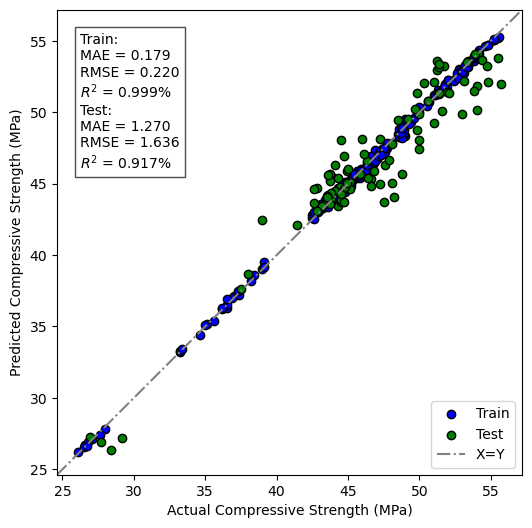

In [144]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_cat_reg,
                            y_test_reg, y_test_pred_cat_reg,
                            train_metrics_cat_reg, test_metrics_cat_reg,
                            colors=['blue', 'green'])

# ANN

In [106]:
# Import tensorflow and the necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from keras_tuner import GridSearch
from keras_tuner import RandomSearch
from sklearn.model_selection import train_test_split
import numpy as np
import random

# Set Random Seed
tf.random.set_seed(RANDOM_SEED)

In [154]:
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train_reg.shape[1],)))
    model.add(Dense(
        units=hp.Int('units', min_value=16, max_value=608, step=8),
        activation=hp.Choice('activation', values=['relu', 'tanh','sigmoid'])
    ))
    for i in range(hp.Int('layers', 2, 5)):
        model.add(Dense(
            units=hp.Int(f'units_{i}', min_value=16, max_value=608, step=8),
            activation=hp.Choice(f'activation_{i}', values=['relu', 'tanh','sigmoid'])
        ))
        model.add(Dropout(rate=hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)))
    model.add(Dense(1))  
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

In [158]:
tuner = RandomSearch( # Use RandomSearch 
    build_model,
    objective='val_mae',
    max_trials=200,  # Adjust based on how many total trials you wish to execute # Set to None to try all combinations
    executions_per_trial=1,  # Ensuring robustness of trial results. However, if seed is fixed, then the models will be the same
    directory='my_dir_grid2',
    project_name='random_search2',
    seed=RANDOM_SEED,
    overwrite = True
)

In [160]:
# Set up the early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Start the hyperparameter search
tuner.search(X_train_reg, y_train_reg,
             epochs=150,
             validation_data=(X_test_reg, y_test_reg),
             callbacks=[early_stopping]
             )

Trial 200 Complete [00h 01m 05s]
val_mae: 1.396407127380371

Best val_mae So Far: 1.2809263467788696
Total elapsed time: 02h 11m 51s


In [162]:
# After tuner.search(), get the best hyperparameters and print them:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"The optimal number of units in the first densely-connected layer is {best_hps.get('units')}.")
print(f"The optimal activation function in the first layer is {best_hps.get('activation')}.")
for i in range(best_hps.get('layers')):
    print(f"The optimal number of units in layer {i+1} is {best_hps.get(f'units_{i}')}.")
    print(f"The optimal activation function in layer {i+1} is {best_hps.get(f'activation_{i}')}.")
    print(f"The optimal dropout rate in layer {i+1} is {best_hps.get(f'dropout_{i}')}.")
print("The chosen optimizer is adam.")

The optimal number of units in the first densely-connected layer is 416.
The optimal activation function in the first layer is relu.
The optimal number of units in layer 1 is 360.
The optimal activation function in layer 1 is relu.
The optimal dropout rate in layer 1 is 0.2.
The optimal number of units in layer 2 is 272.
The optimal activation function in layer 2 is tanh.
The optimal dropout rate in layer 2 is 0.0.
The optimal number of units in layer 3 is 528.
The optimal activation function in layer 3 is relu.
The optimal dropout rate in layer 3 is 0.2.
The chosen optimizer is adam.


In [164]:
# Build the best model
model = tuner.hypermodel.build(best_hps)

# Display the model architecture
model.summary()

# Train the model with early stopping
model.fit(X_train_reg, y_train_reg, epochs=150, validation_data=(X_test_reg, y_test_reg), callbacks=[early_stopping])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 416)            │         4,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 360)            │       150,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 360)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 272)            │        98,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 272)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 528)            │       144,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 528)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,977 (1.52 MB)

 Trainable params: 397,977 (1.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 2056.7520 - mae: 44.9167 - val_loss: 1433.9222 - val_mae: 37.4784
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 978.8243 - mae: 29.3853 - val_loss: 34.1765 - val_mae: 4.2211
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 152.1308 - mae: 9.7254 - val_loss: 121.8826 - val_mae: 9.6649
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 87.2982 - mae: 7.4339 - val_loss: 66.6599 - val_mae: 7.2193
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 82.3104 - mae: 8.0939 - val_loss: 62.4208 - val_mae: 6.9199
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 56.2793 - mae: 6.2080 - val_loss: 31.2339 - val_mae: 4.2616
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 43.2801 - mae: 4.9209 - val_loss: 28.5928 - val_mae: 4.1287
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 36.1022 - mae: 4.6276 - val_loss: 34.0048 - val_mae: 4.4437
Epoch 9/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/

In [166]:
# Make predictions
y_train_pred_nn = model.predict(X_train_reg).flatten()
y_test_pred_nn = model.predict(X_test_reg).flatten()
y_complete_pred_nn = model.predict(X_reg).flatten()

# Do Evaluations
train_metrics_nn = evaluate_predictions(y_train_reg, y_train_pred_nn)
test_metrics_nn = evaluate_predictions(y_test_reg, y_test_pred_nn)
complete_metrics_nn = evaluate_predictions(y_reg, y_complete_pred_nn)

# Printing the results
print_results(train_metrics_nn , 'Train_nn')
print_results(test_metrics_nn , 'Test_nn')
print_results(complete_metrics_nn , 'Complete dataset_nn')

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Train_nn MAE = 1.17
Train_nn MSE = 2.308
Train_nn RMSE = 1.519
Train_nn MAPE = 0.026%
Train_nn R2 = 0.942%

Test_nn MAE = 1.285
Test_nn MSE = 2.843
Test_nn RMSE = 1.686
Test_nn MAPE = 0.028%
Test_nn R2 = 0.911%

Complete dataset_nn MAE = 1.204
Complete dataset_nn MSE = 2.468
Complete dataset_nn RMSE = 1.571
Complete dataset_nn MAPE = 0.026%
Complete dataset_nn R2 = 0.934%



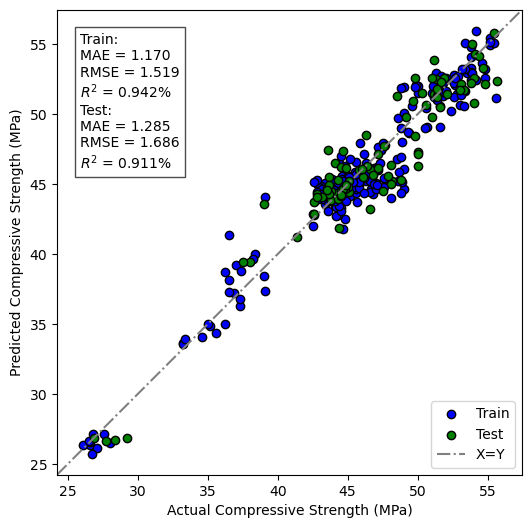

In [168]:
# Create single plot
fig, ax = plt.subplots(figsize=(6, 8))

# Call the combined plotting function
create_combined_scatter_plot(ax, 
                            y_train_reg, y_train_pred_nn,
                            y_test_reg, y_test_pred_nn,
                            train_metrics_nn, test_metrics_nn,
                            colors=['blue', 'green'])

# Taylor diagram calculations

In [170]:
# standard deviations
# Reference dataset
reference_std1 = np.std(target_reg)

In [188]:
reference_std1

6.120067130924375

In [190]:
def calculate_error_std(y_pred):
  return np.std(y_pred)

In [342]:
train_std_nn = calculate_error_std( y_train_pred_nn)
test_std_nn = calculate_error_std(y_test_pred_nn)

print(f"Train nn: {train_std_nn}")
print(f"Test nn: {test_std_nn}")

Train nn: 7.615530014038086
Test nn: 7.779122829437256


In [192]:
std_lr_train = calculate_error_std(y_train_pred_lr)
std_lr_test = calculate_error_std(y_test_pred_lr)
std_lr_complete = calculate_error_std(y_complete_pred_lr)

std_train_KNN = calculate_error_std(y_train_pred_KNN)
std_test_KNN = calculate_error_std(y_test_pred_KNN)
std_complete_KNN = calculate_error_std(y_complete_pred_KNN)

train_std_svr = calculate_error_std(y_train_pred_svr)
test_std_svr = calculate_error_std(y_test_pred_svr)
complete_std_svr = calculate_error_std(y_complete_pred_svr)

train_std_dt = calculate_error_std(y_train_pred_dt0)
test_std_dt = calculate_error_std(y_test_pred_dt0)
complete_std_dt = calculate_error_std(y_complete_pred_dt0)

train_std_rf = calculate_error_std(y_train_pred_rf0)
test_std_rf = calculate_error_std(y_test_pred_rf0)
complete_std_rf = calculate_error_std(y_complete_pred_rf0)

train_std_extra_trees = calculate_error_std(y_train_pred_extra_trees)
test_std_extra_trees = calculate_error_std( y_test_pred_extra_trees)
complete_std_extra_trees = calculate_error_std(y_complete_pred_extra_trees)

train_std_adaboost = calculate_error_std( y_train_pred_adaboost)
test_std_adaboost = calculate_error_std( y_test_pred_adaboost)
complete_std_adaboost = calculate_error_std( y_complete_pred_adaboost)

train_std_gbm = calculate_error_std( y_train_pred_gbm)
test_std_gbm = calculate_error_std( y_test_pred_gbm)
complete_std_gbm = calculate_error_std( y_complete_pred_gbm)

train_std_xgb = calculate_error_std( y_train_pred_xgb0)
test_std_xgb = calculate_error_std( y_test_pred_xgb0)
complete_std_xgb = calculate_error_std( y_complete_pred_xgb0)

train_std_lgbm = calculate_error_std(y_train_pred_lgbm0)
test_std_lgbm = calculate_error_std(y_test_pred_lgbm0)
complete_std_lgbm = calculate_error_std(y_complete_pred_lgbm0)

train_std_cat_reg = calculate_error_std(y_train_pred_cat_reg)
test_std_cat_reg = calculate_error_std(y_test_pred_cat_reg)
complete_std_cat_reg = calculate_error_std(y_complete_pred_cat_reg)

train_std_nn = calculate_error_std(y_train_pred_nn)
test_std_nn = calculate_error_std(y_test_pred_nn)
complete_std_nn = calculate_error_std(y_complete_pred_nn)

In [194]:
print(f"Train lr: {std_lr_train}")
print(f"Test lr: {std_lr_test}")
print(f"Test lr: {std_lr_complete}")

print(f"Train KNN: {std_train_KNN}")
print(f"Test KNN: {std_test_KNN}")
print(f"Test KNN: {std_complete_KNN}")

print(f"Train svr: {train_std_svr}")
print(f"Test svr: {test_std_svr}")
print(f"Test svr: {complete_std_svr}")

print(f"Train dt_opt: {train_std_dt}")
print(f"Test dt_opt: {test_std_dt}")
print(f"Test dt_opt: {complete_std_dt}")

print(f"Train rf_opt: {train_std_rf}")
print(f"Test rf_opt: {test_std_rf}")
print(f"Test rf_opt: {complete_std_rf}")

print(f"Train et_opt: {train_std_extra_trees}")
print(f"Test et_opt: {test_std_extra_trees}")
print(f"Test et_opt: {complete_std_extra_trees}")

print(f"Train ada_opt: {train_std_adaboost}")
print(f"Test ada_opt: {test_std_adaboost}")
print(f"Test ada_opt: {complete_std_adaboost}")

print(f"Train gbm_opt: {train_std_gbm}")
print(f"Test gbm_opt: {test_std_gbm}")
print(f"Test gbm_opt: {complete_std_gbm}")

print(f"Train xgb_opt: {train_std_xgb}")
print(f"Test xgb_opt: {test_std_xgb}")
print(f"Test xgb_opt: {complete_std_xgb}")

print(f"Train lgbm_opt: {train_std_lgbm}")
print(f"Test lgbm_opt: {test_std_lgbm}")
print(f"Test lgbm_opt: {complete_std_lgbm}")

print(f"Train cat: {train_std_cat_reg}")
print(f"Test cat: {test_std_cat_reg}")
print(f"Test cat: {complete_std_cat_reg}")

print(f"Train nn: {train_std_nn}")
print(f"Test nn: {test_std_nn}")
print(f"Test nn: {complete_std_nn}")

Train lr: 5.392010410343826
Test lr: 5.552802584118247
Test lr: 5.452278200405825
Train KNN: 6.284999039513587
Test KNN: 5.6865027474730985
Test KNN: 6.123131090404591
Train svr: 5.898276362157997
Test svr: 5.606675137412866
Test svr: 5.823851816816262
Train dt_opt: 5.8581285780667365
Test dt_opt: 5.442794814392687
Test dt_opt: 5.742514345096134
Train rf_opt: 6.080241250908684
Test rf_opt: 5.543002832137207
Test rf_opt: 5.933018369337645
Train et_opt: 6.253662573992612
Test et_opt: 5.573388966842309
Test et_opt: 6.070238497636455
Train ada_opt: 6.115305660500015
Test ada_opt: 5.472716061294464
Test ada_opt: 5.9414251682833426
Train gbm_opt: 6.2407802828726915
Test gbm_opt: 5.8398834613198725
Test gbm_opt: 6.139503261944434
Train xgb_opt: 6.230062484741211
Test xgb_opt: 5.7097649574279785
Test xgb_opt: 6.091514587402344
Train lgbm_opt: 6.274038656137477
Test lgbm_opt: 5.724120385886
Test lgbm_opt: 6.1263831970610285
Train cat: 6.247837918270276
Test cat: 5.529569068138649
Test cat: 6.05